In [18]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
import numpy as np
import numpy
import matplotlib.cm as cmap
from sklearn.preprocessing import StandardScaler
import umap.plot
from sklearn.cluster import KMeans
import sys
sys.path.insert(0, r'C:\Users\nVoke\PycharmProjects\pythonProject1\tools')


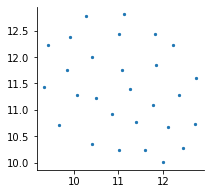

In [ ]:

root_path = r'F:\jcy\humen_brain\revision20251127\Q4'
seed_num = 6
np.random.seed(seed_num)
summary_features=pd.read_excel(root_path+'\\excitory.xlsx',index_col=0)

prefix = 'excitory'
summary_features.fillna(method = 'pad', axis =0, inplace=True, limit=None)
sum_fea_scaler=StandardScaler().fit_transform(summary_features)
sum_fea_scaler=pd.DataFrame(sum_fea_scaler,index=summary_features.index,columns=summary_features.columns)
umap_vals = umap.UMAP(n_neighbors=25,n_components=2, random_state=seed_num).fit_transform(sum_fea_scaler)

plt.figure(figsize=(3,3),facecolor='white')
plt.scatter(*umap_vals.T,s=5,edgecolors=None)
sns.despine()

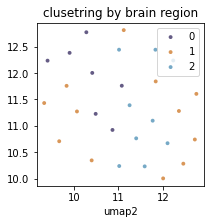

In [20]:
sum_fea_scaler['tagets']=[i[:8] for i in sum_fea_scaler.index]
tagets=sum_fea_scaler['tagets']
encoder = LabelEncoder()
tagets = encoder.fit_transform(tagets)
encoder.classes_, np.unique(tagets, return_counts=True)
plt.figure(figsize=(3,3))
for color, i in zip(['#655c85','#d99759','#76a9c6'], [0, 1, 2]):
    plt.scatter(umap_vals[tagets==i, 0], umap_vals[tagets==i, 1],s=15, c=color, label=i,edgecolors='none',linewidths=0)
    plt.legend()
plt.title('clusetring by brain region');plt.xlabel('umap1');plt.xlabel('umap2')
plt.savefig(root_path+f'\\clusetring by brain region_{prefix}.pdf')

Index(['threshold_v', 'latency', 'peak_v', 'trough_v', 'peak_amp',
       'upstroke_downstroke_ratio', 'adaptation', 'isi_cv', 'avg_rate', 'tau',
       'sag', 'Rin', 'Cm', 'half_width', 'DepoR', 'RepoR', 'AHPAmp',
       'AHP_latency', 'RMP', 'IS1', 'IS2'],
      dtype='object')


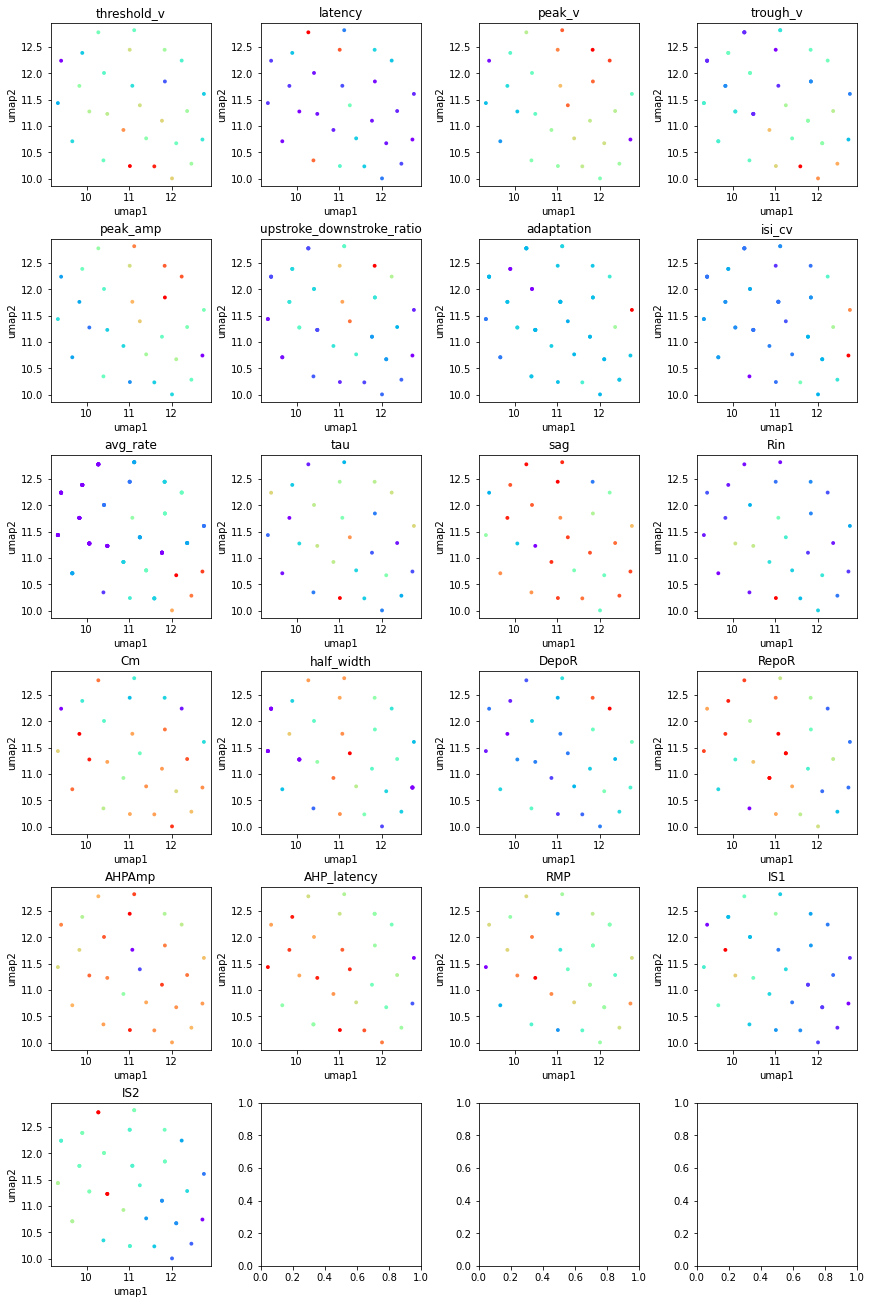

In [ ]:
parameters=sum_fea_scaler.columns[:-1]
print(parameters)
plt.subplots(nrows=6, ncols=4, figsize=(12,18),constrained_layout=True)
for i in enumerate(parameters):
    r =sum_fea_scaler[i[1]].values
    c = cmap.rainbow(numpy.int_((r-r.min())/r.ptp()*255))
    plt.subplot(6,4,i[0]+1)
    for color, cell in zip(c, r):
        plt.scatter(umap_vals[r==cell, 0], umap_vals[r==cell, 1],s=15, c=np.array(color).reshape(1,-1),edgecolors='none',linewidths=0)
    plt.title(i[1]);plt.xlabel('umap1');plt.ylabel('umap2')
plt.savefig(root_path+f'\\clusetring by parameters_{prefix}.pdf')
